유방암 진단 데이터셋을 활용하여, 단층 퍼셉트론으로 이진 분류 모델을 구현한다.
입력은 10개 feature, 출력은 1개의 확률값
Sigmoid 함수를 통해 확률 기반 분류를 수행한다.

0. 필요한 라이브러리 import

In [19]:
import pandas as pd 
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer

1. 데이터 불러오기

In [20]:
cancer = load_breast_cancer()       # Bunch 객체 형식으로 가져온다.
cancer

{'data': array([[1.799e+01, 1.038e+01, 1.228e+02, ..., 2.654e-01, 4.601e-01,
         1.189e-01],
        [2.057e+01, 1.777e+01, 1.329e+02, ..., 1.860e-01, 2.750e-01,
         8.902e-02],
        [1.969e+01, 2.125e+01, 1.300e+02, ..., 2.430e-01, 3.613e-01,
         8.758e-02],
        ...,
        [1.660e+01, 2.808e+01, 1.083e+02, ..., 1.418e-01, 2.218e-01,
         7.820e-02],
        [2.060e+01, 2.933e+01, 1.401e+02, ..., 2.650e-01, 4.087e-01,
         1.240e-01],
        [7.760e+00, 2.454e+01, 4.792e+01, ..., 0.000e+00, 2.871e-01,
         7.039e-02]], shape=(569, 30)),
 'target': array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0,
        0, 0, 1, 0, 1, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 1, 1, 1, 0, 1, 0, 0,
        1, 1, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0,
        1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 1,
        1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1,

In [21]:
cancer.DESCR    # 데이터셋의 상세 설명

'.. _breast_cancer_dataset:\n\nBreast cancer Wisconsin (diagnostic) dataset\n--------------------------------------------\n\n**Data Set Characteristics:**\n\n:Number of Instances: 569\n\n:Number of Attributes: 30 numeric, predictive attributes and the class\n\n:Attribute Information:\n    - radius (mean of distances from center to points on the perimeter)\n    - texture (standard deviation of gray-scale values)\n    - perimeter\n    - area\n    - smoothness (local variation in radius lengths)\n    - compactness (perimeter^2 / area - 1.0)\n    - concavity (severity of concave portions of the contour)\n    - concave points (number of concave portions of the contour)\n    - symmetry\n    - fractal dimension ("coastline approximation" - 1)\n\n    The mean, standard error, and "worst" or largest (mean of the three\n    worst/largest values) of these features were computed for each image,\n    resulting in 30 features.  For instance, field 0 is Mean Radius, field\n    10 is Radius SE, field 

In [22]:
# df으로 만들어준다.
df = pd.DataFrame(cancer.data, columns=cancer.feature_names)
df['class'] = cancer.target
df

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,class
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.16220,0.66560,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,0.1726,0.05623,...,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115,0
565,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,0.1752,0.05533,...,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637,0
566,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,0.1590,0.05648,...,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820,0
567,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,0.2397,0.07016,...,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400,0


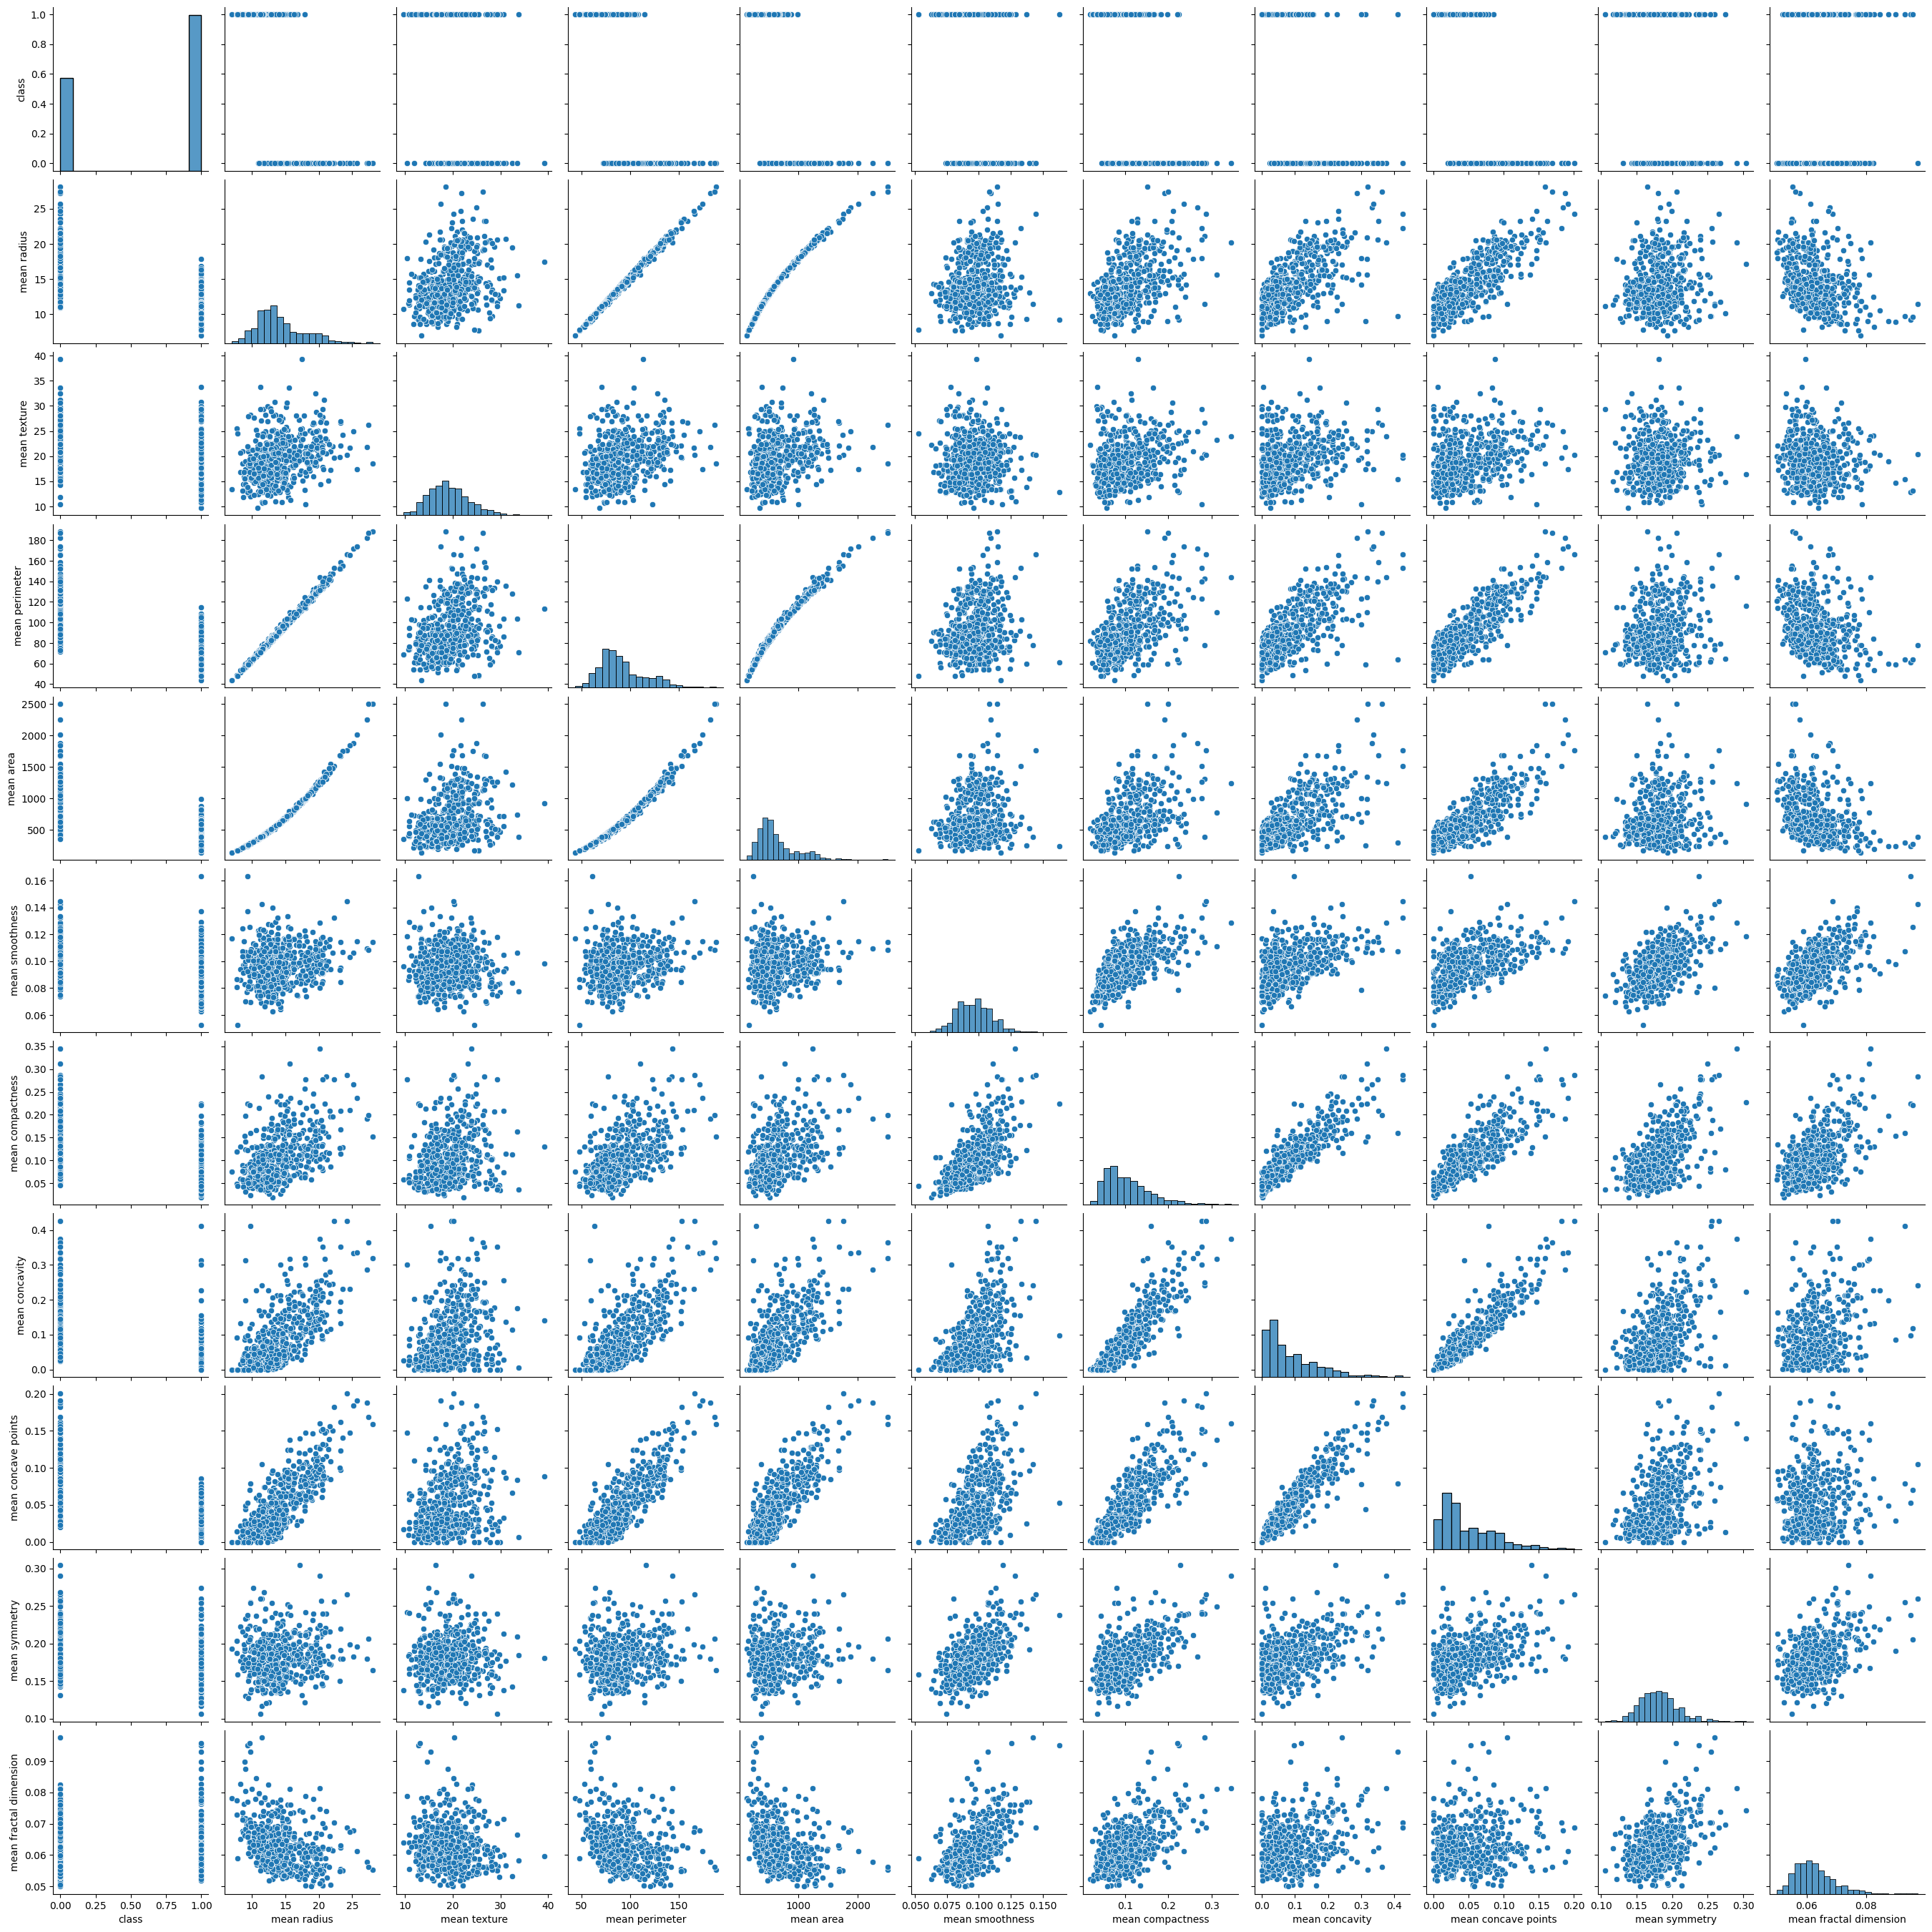

In [23]:
# 평균 특성들로 구성된 페어플롯 (mean으로 시작하는 특성)
sns.pairplot(
    df[['class'] + list(df.columns[:10])]
)
plt.show()

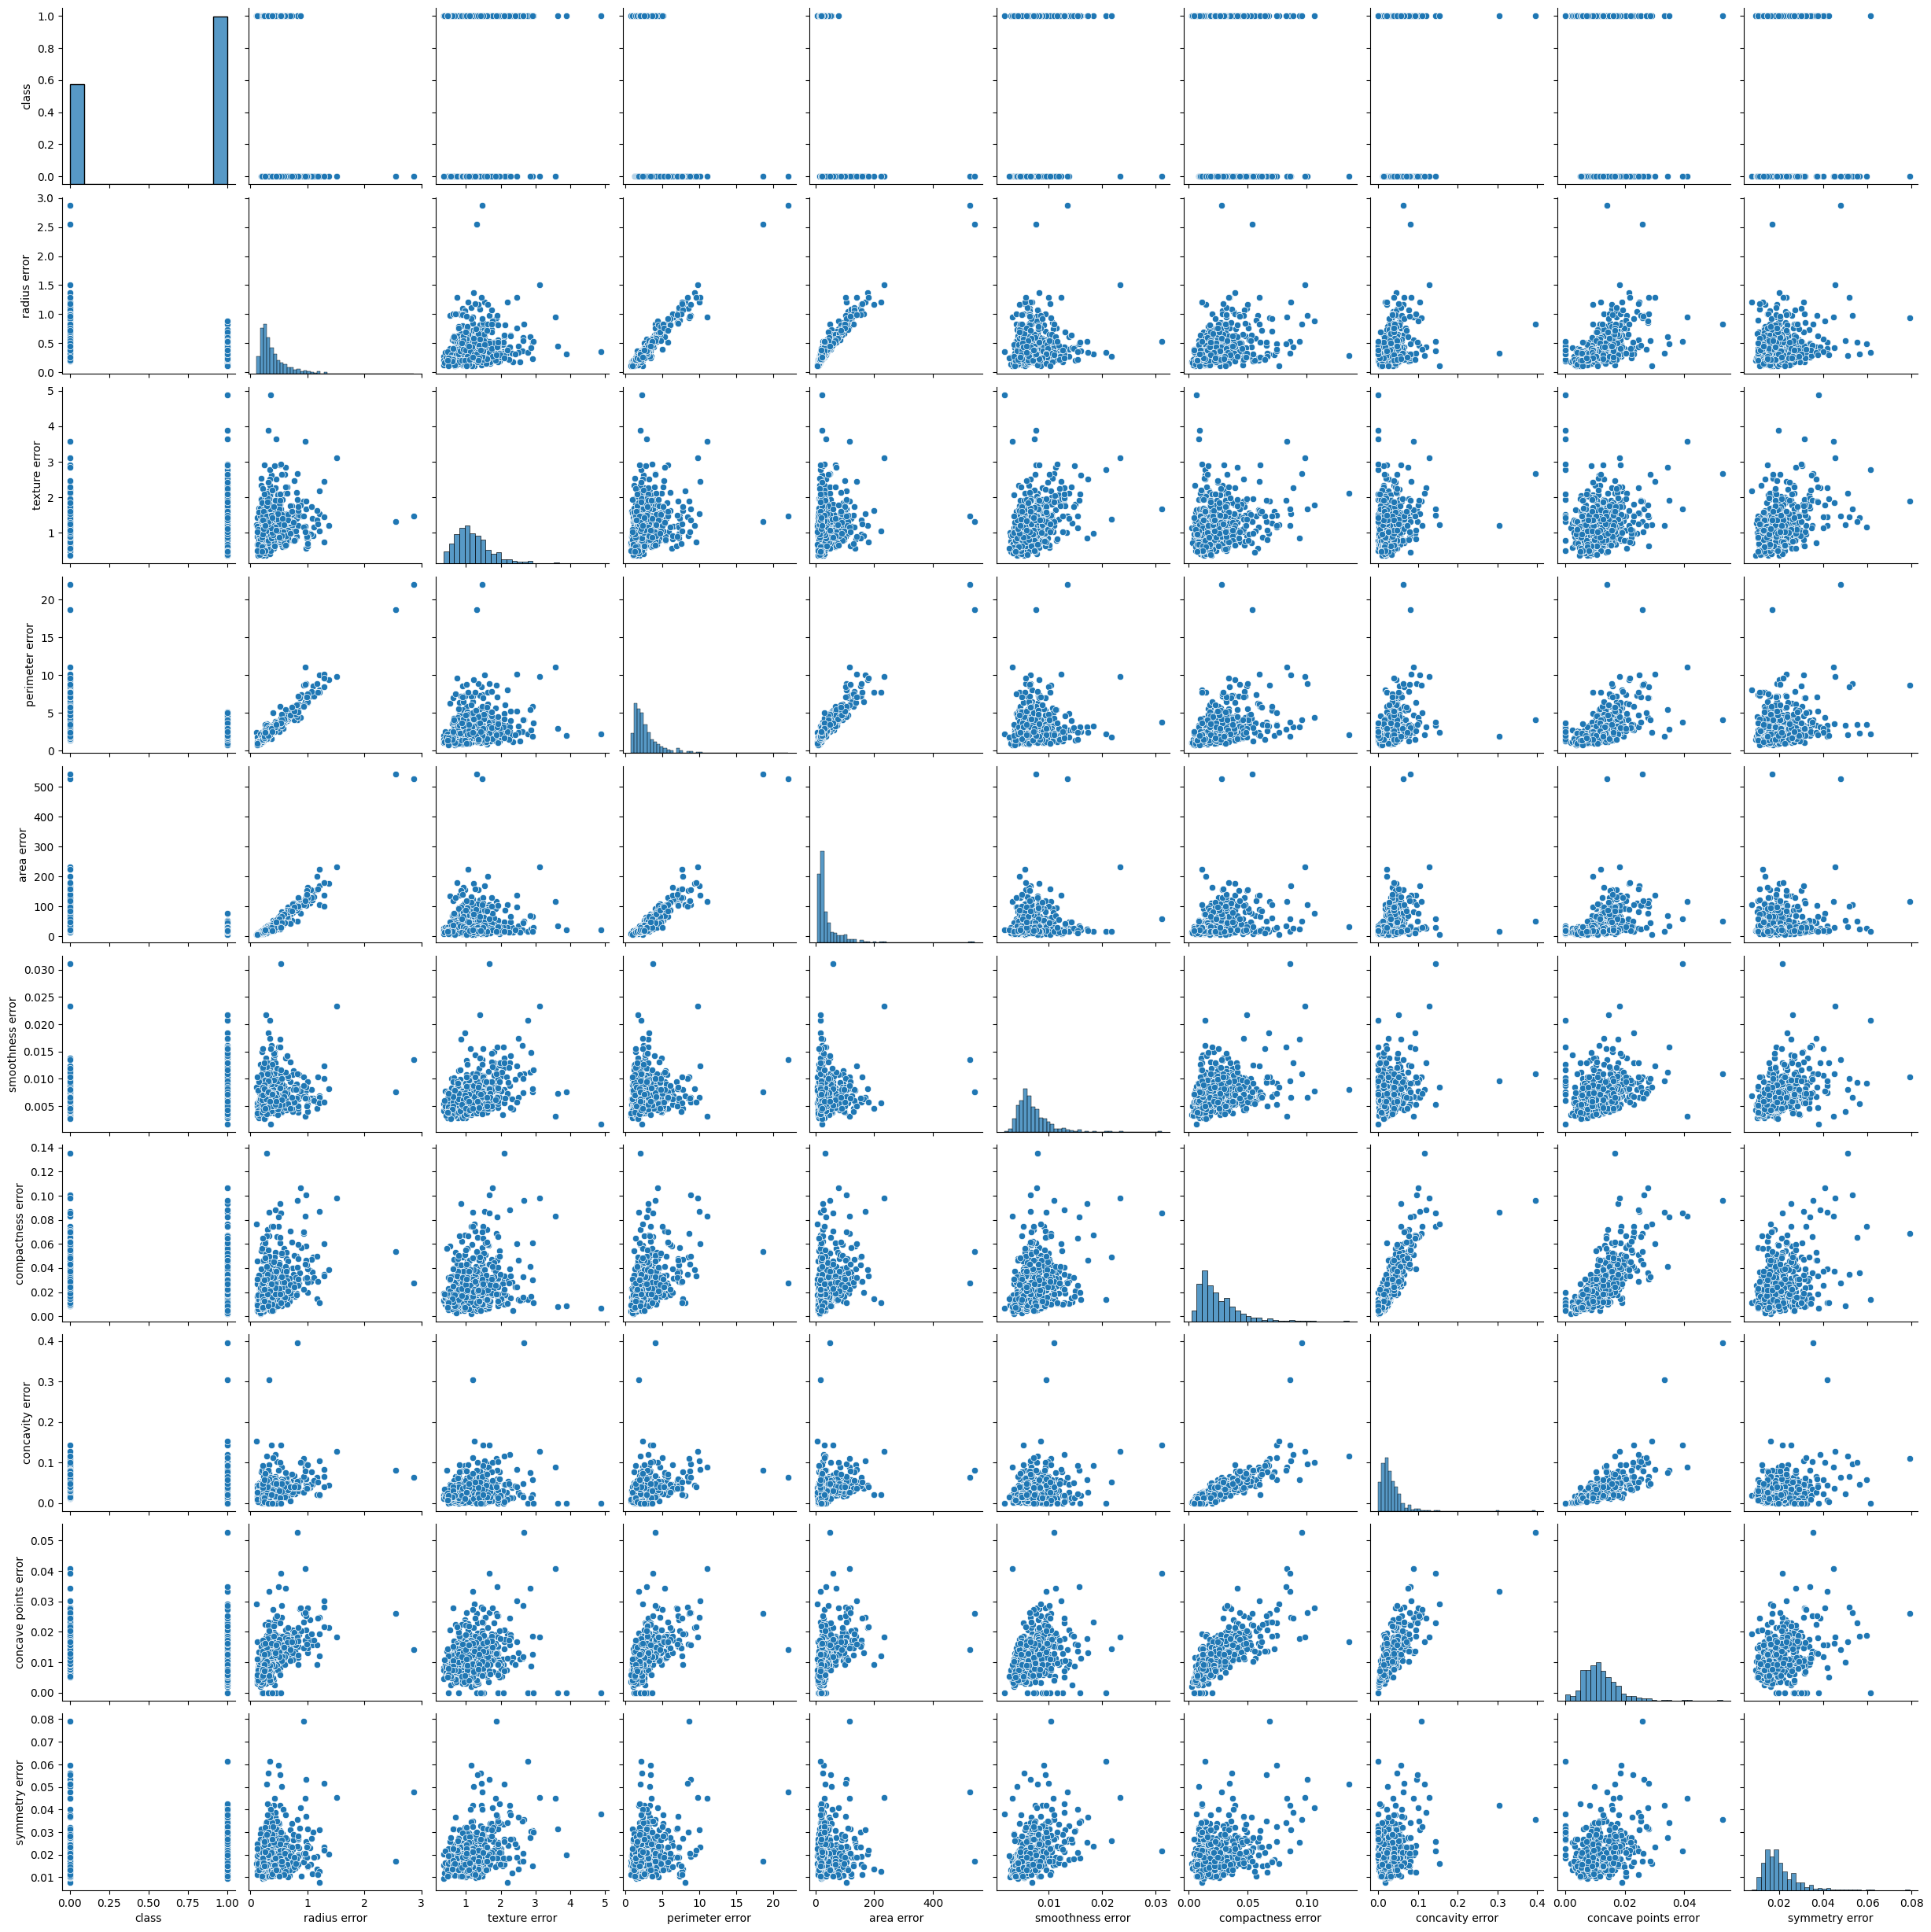

In [24]:
# 표준편차 특성들로 구성된 페어플롯 (error로 끝나는 특성)
sns.pairplot(df[['class'] + list(df.columns[10:19])])
plt.show()

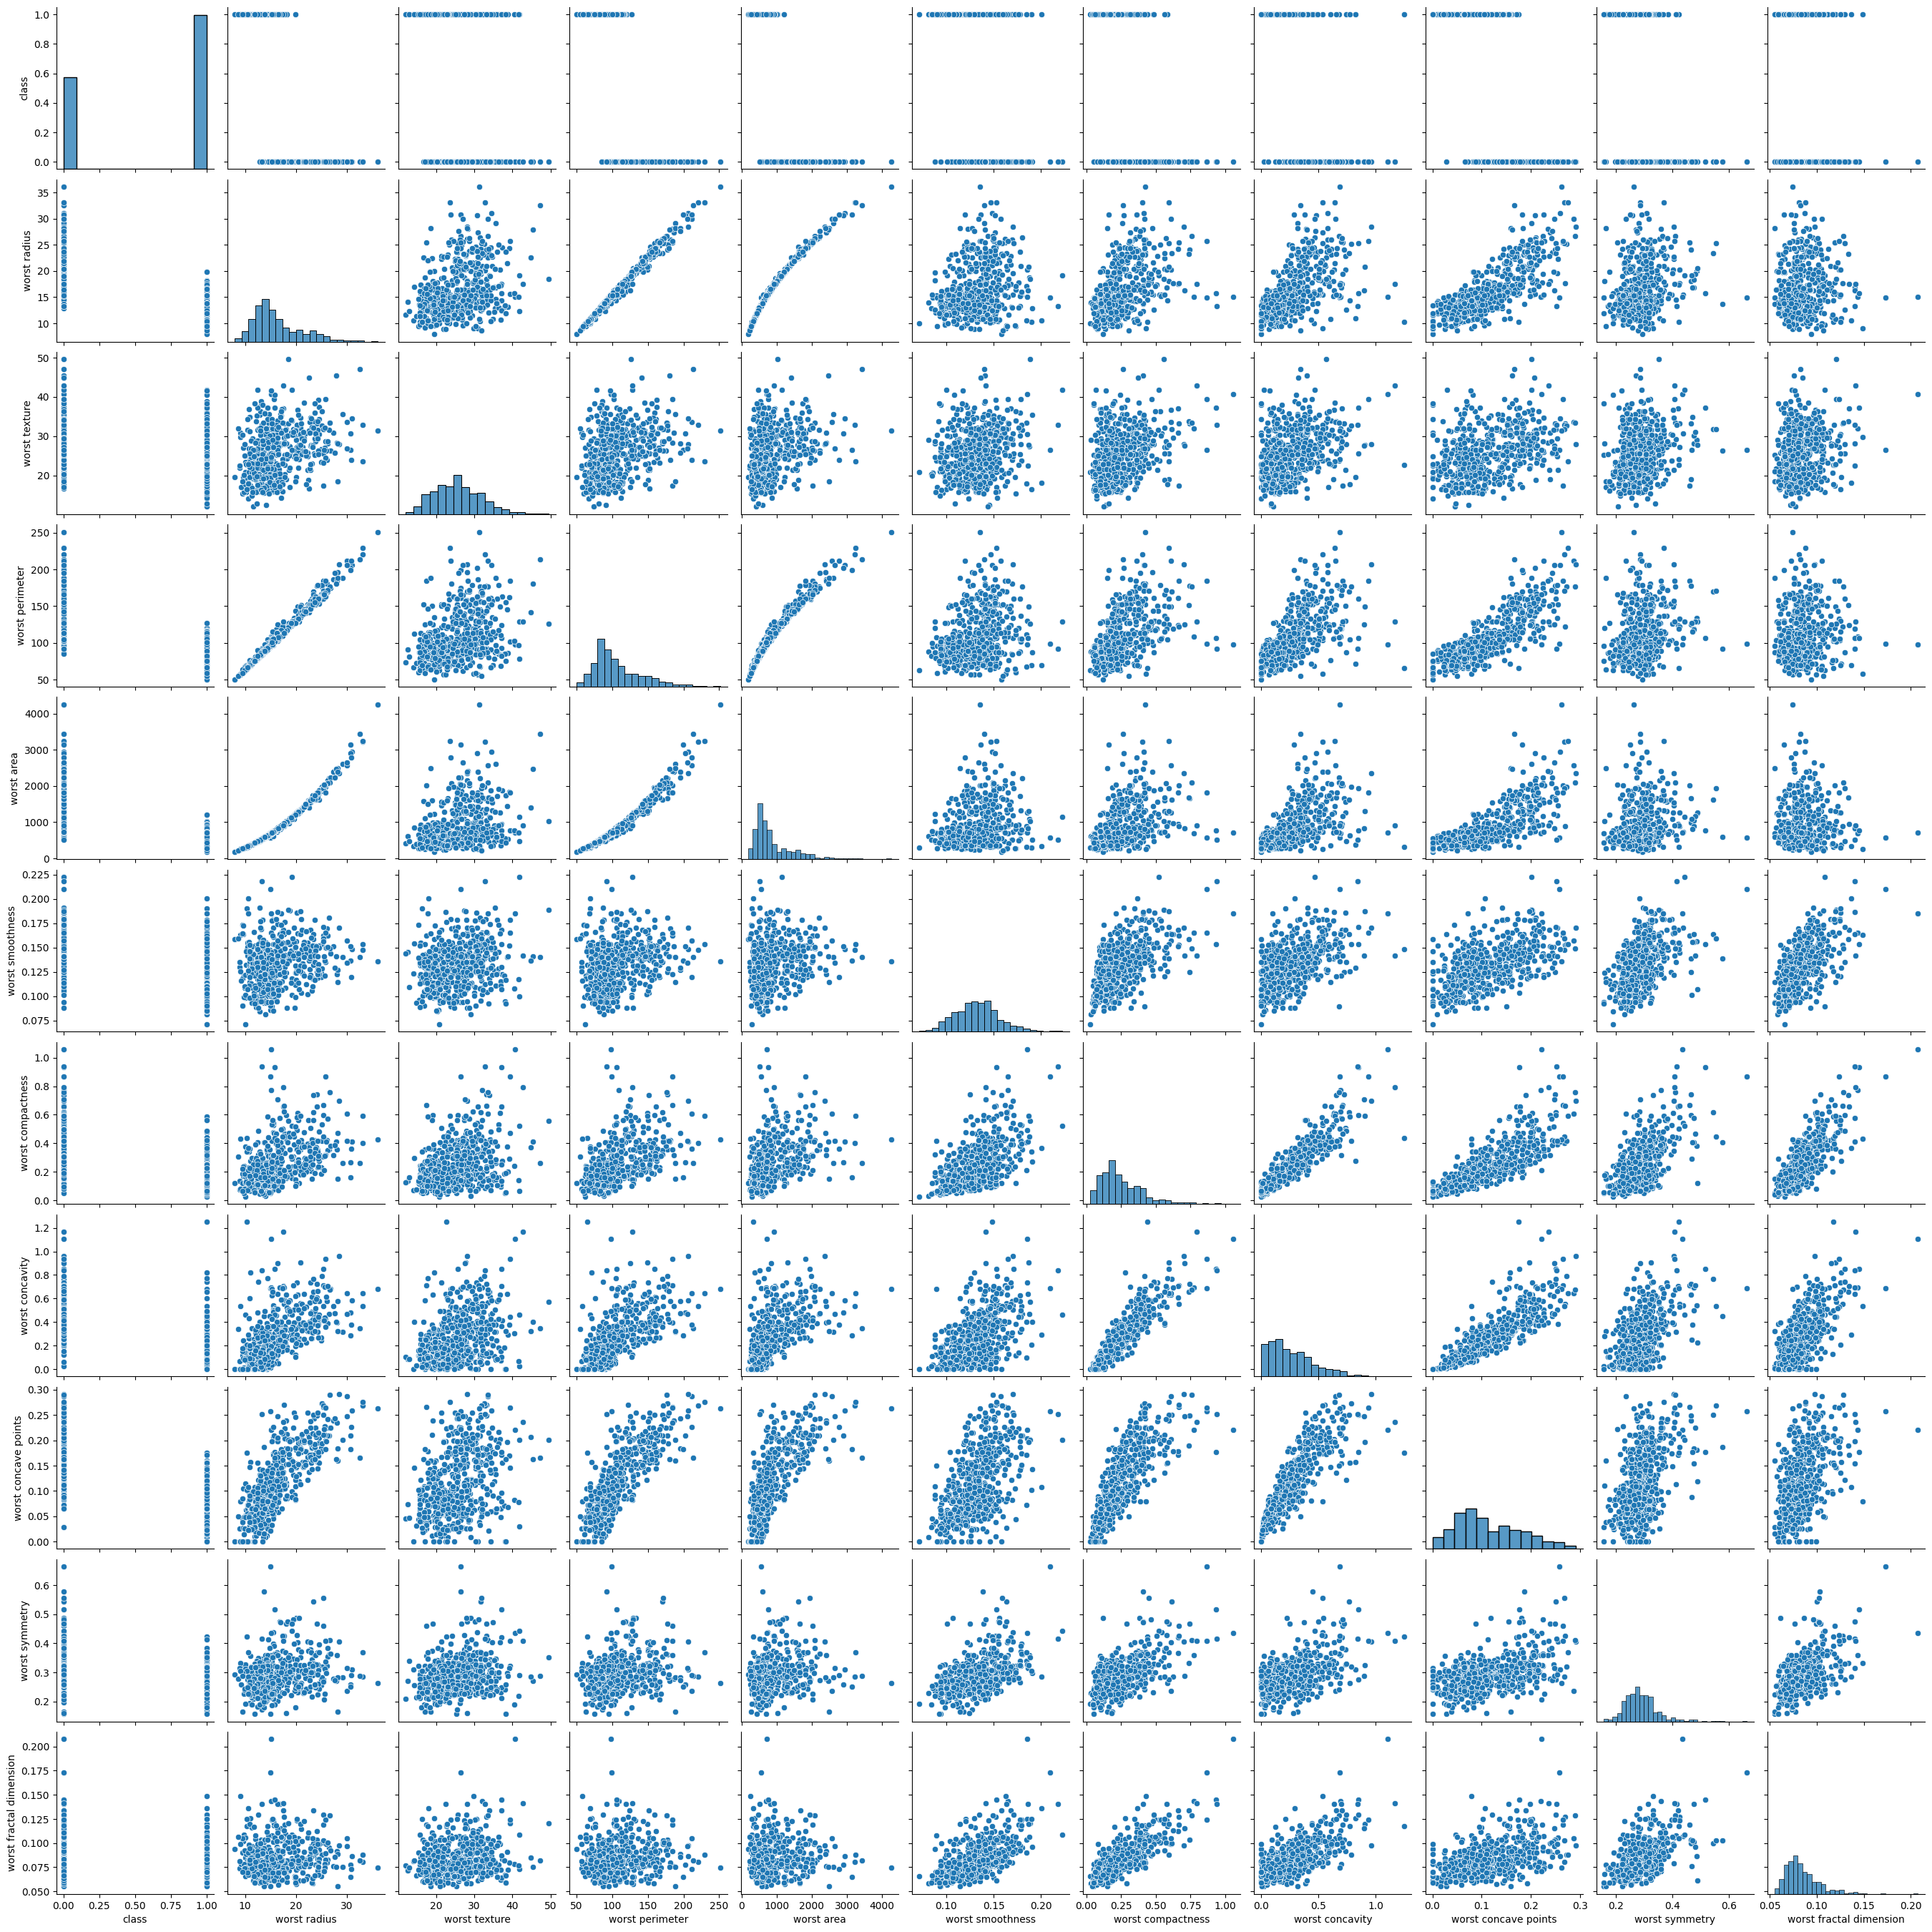

In [25]:
# 최악 특성들로 구성된 페어플롯 (worst로 시작하는 특성)
sns.pairplot(df[['class'] + list(df.columns[20:30])])
plt.show()

In [26]:
cancer.feature_names

array(['mean radius', 'mean texture', 'mean perimeter', 'mean area',
       'mean smoothness', 'mean compactness', 'mean concavity',
       'mean concave points', 'mean symmetry', 'mean fractal dimension',
       'radius error', 'texture error', 'perimeter error', 'area error',
       'smoothness error', 'compactness error', 'concavity error',
       'concave points error', 'symmetry error',
       'fractal dimension error', 'worst radius', 'worst texture',
       'worst perimeter', 'worst area', 'worst smoothness',
       'worst compactness', 'worst concavity', 'worst concave points',
       'worst symmetry', 'worst fractal dimension'], dtype='<U23')

In [27]:
cols = ['mean radius', 'mean texture', 'mean smoothness',
        'mean compactness', 'mean concave points',
        'worst radius', 'worst texture', 'worst smoothness',
        'worst compactness', 'worst concave points',
        'class']

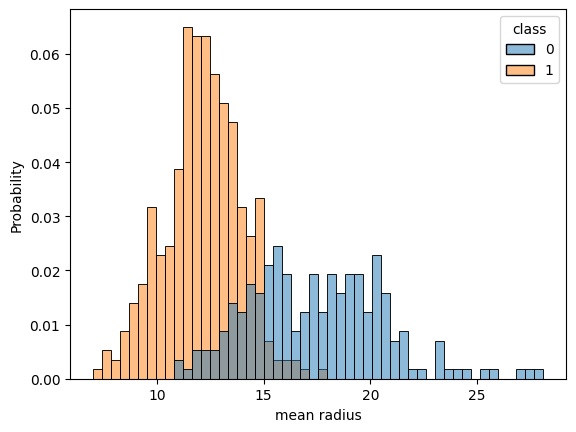

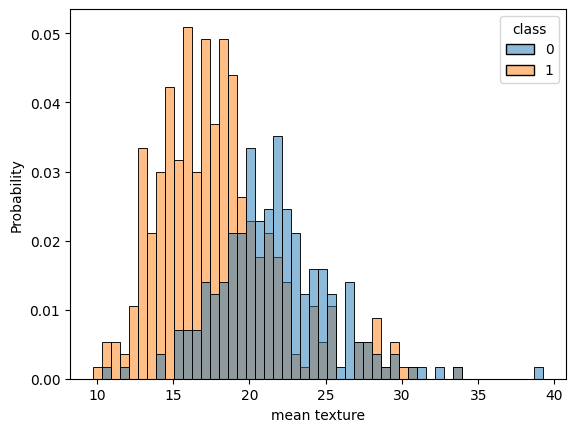

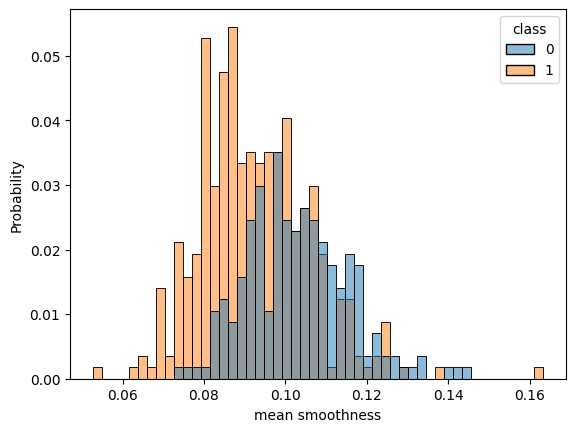

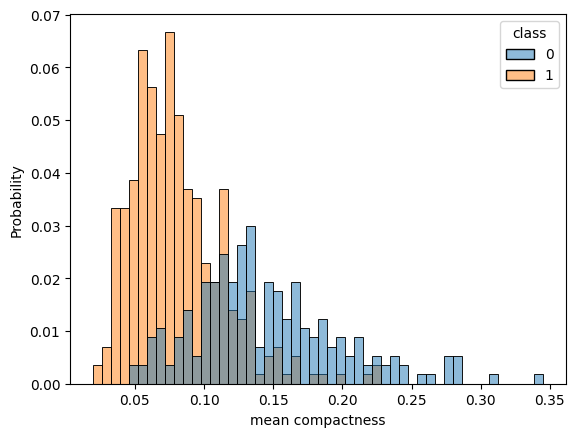

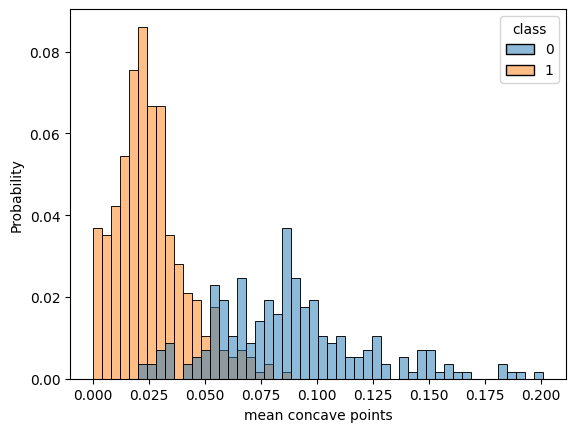

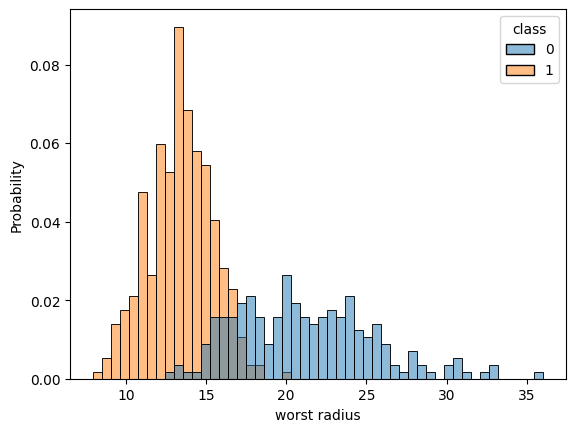

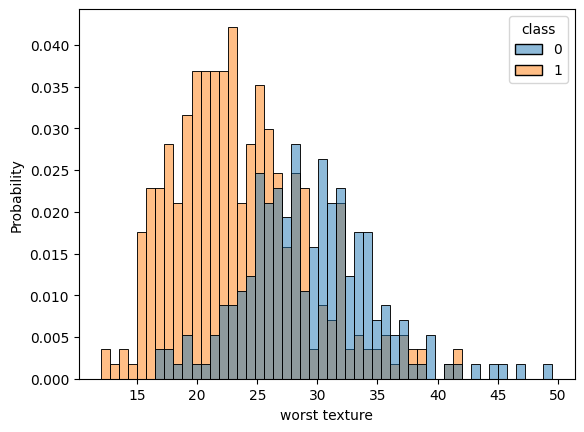

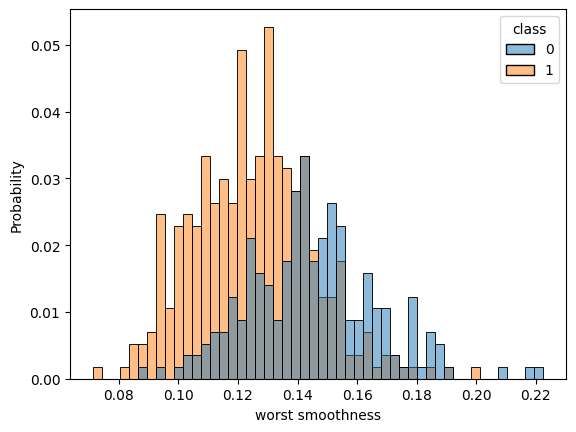

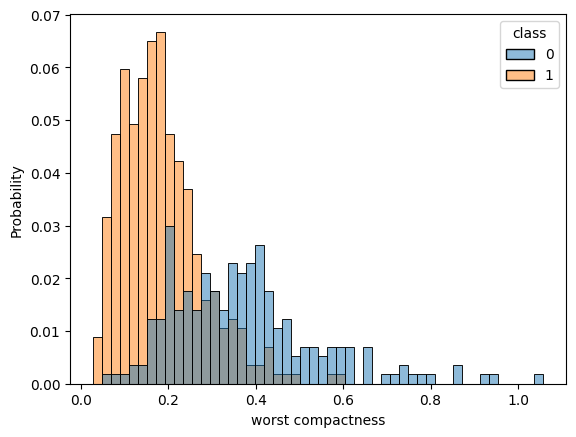

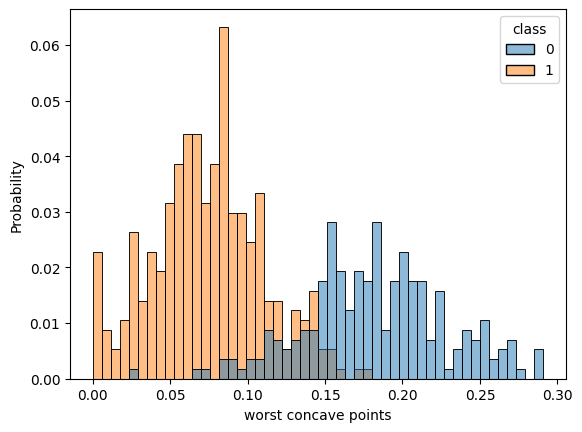

In [28]:
for c in cols[:-1]:             # 마지막 컬럼(class) 제외한 컬럼
    sns.histplot(
        df,
        x=c,                    # 현재 특성 컬럼이 x축
        hue=cols[-1],           # 마지막 컬럼(class) 기준으로 색상 구분
        bins=50,                # 히스토그램 구간 50개
        stat='probability'      # 빈도를 확률(비율)로 정규화하여 비교
    )
    
    plt.show()

In [29]:
import torch                        # 텐서 연산
import torch.nn as nn               # 신경망 레이어와 모델
import torch.nn.functional as F     # 활성화 함수, 손실함수 등 함수
import torch.optim as optim         # SGD, Adam 등 최적화 알고리즘

In [30]:
data = torch.from_numpy(df[cols].values).float()    # 해당 컬럼값을 Numpy 배열 -> Pytorch FloatTensor로 변환 

data.size()

torch.Size([569, 11])

In [31]:
data

tensor([[17.9900, 10.3800,  0.1184,  ...,  0.6656,  0.2654,  0.0000],
        [20.5700, 17.7700,  0.0847,  ...,  0.1866,  0.1860,  0.0000],
        [19.6900, 21.2500,  0.1096,  ...,  0.4245,  0.2430,  0.0000],
        ...,
        [16.6000, 28.0800,  0.0846,  ...,  0.3094,  0.1418,  0.0000],
        [20.6000, 29.3300,  0.1178,  ...,  0.8681,  0.2650,  0.0000],
        [ 7.7600, 24.5400,  0.0526,  ...,  0.0644,  0.0000,  1.0000]])

In [ ]:
# 입력값(X)와 정답값(y)를 분리 (범위형으로 자른다.)
X = data[:,:-1]
y = data[:,-1:]
print(X.shape)
print(y.shape)
print(X)
print(y)

torch.Size([569, 10])
torch.Size([569, 1])
tensor([[17.9900, 10.3800,  0.1184,  ...,  0.1622,  0.6656,  0.2654],
        [20.5700, 17.7700,  0.0847,  ...,  0.1238,  0.1866,  0.1860],
        [19.6900, 21.2500,  0.1096,  ...,  0.1444,  0.4245,  0.2430],
        ...,
        [16.6000, 28.0800,  0.0846,  ...,  0.1139,  0.3094,  0.1418],
        [20.6000, 29.3300,  0.1178,  ...,  0.1650,  0.8681,  0.2650],
        [ 7.7600, 24.5400,  0.0526,  ...,  0.0900,  0.0644,  0.0000]])
tensor([[0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [1.],
        [1.],
        [1.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
     

In [37]:
# 학습 관련 하이퍼파라미터 설정
n_epochs = 200000           # 학습 반복 횟수
learning_rate = 1e-2        # 학습률(0.01)
print_interval = 10000      # 학습 진행상황 출력 간격


In [43]:
# nn.Module을 상속 받아 입력 -> 선형 변환 -> 활성화 함수로 구성된 클래스
class MyModel(nn.Module):
    
    def __init__(self, input_dim, output_dim):
        self.input_dim = input_dim                          # 입력 특성의 차원 수
        self.output_dim = output_dim                        # 출력 차원(노드) 수 
        
        super().__init__()                                  # nn.Module 초기화 : nn.Module에서 내부적으로 관리하는 기능들을 초기화하여 수동 상태 관리한다.
        
        self.linear = nn.Linear(input_dim, output_dim)      # 입력 -> 출력으로 선형 변환
        self.act = nn.Sigmoid()                             # 출력값을 0~1 사이의 범위로 변환하는 활성화함수
    
    def forward(self, x):
        y = self.act(self.linear(x))                        # 선형 변환 후 Sigmoid 활성화 적용
        
        return y                                            # 최종 예측 결과 반환
    

In [49]:
model = MyModel(
    input_dim = X.size(-1),             # 입력 데이터의 마지막 차원 = 입력 노드 수 
    output_dim = y.size(-1)             # 출력 데이터의 마지막 차원 = 출력 노드 수 
)

crit = nn.BCELoss()                     # 이진분류 Sigmoid -> BCE Loss
optimizer = optim.SGD(                 
    model.parameters(),                 # 학습 대상 파라미터 (가중치, 편향)
    lr = learning_rate                  # 경사하강법에서 사용할 학습률
)

In [51]:
# 학습 루프
for i in range(n_epochs):
    y_hat = model(X)                    # 순전파 : 입력 X에 대해 예측값 계산
    loss = crit(y_hat, y)               # 예측값과 실제값을 비교해 손실 계산
    
    optimizer.zero_grad()               # 최적화함수 : 이전 반복의 누적된 기울기 초기화
    loss.backward()                     # 손실함수 : 손실에 대한 파라미터 기울기 계산 (역전파)
    
    optimizer.step()                    # 최적화 함수 : 계산된 기울기를 가지고 파라미터 업데이트
    
    # 지정된 간격마다 출력
    if (i+1) % print_interval == 0:
        print(f"Epoch {i+1}: loss = {loss}")

Epoch 10000: loss = 0.11487442255020142
Epoch 20000: loss = 0.113905169069767
Epoch 30000: loss = 0.11299790441989899
Epoch 40000: loss = 0.11217302083969116
Epoch 50000: loss = 0.11139124631881714
Epoch 60000: loss = 0.11067415028810501
Epoch 70000: loss = 0.10998862236738205
Epoch 80000: loss = 0.10936242341995239
Epoch 90000: loss = 0.1087597981095314
Epoch 100000: loss = 0.10819956660270691
Epoch 110000: loss = 0.10767197608947754
Epoch 120000: loss = 0.10715962946414948
Epoch 130000: loss = 0.10668458044528961
Epoch 140000: loss = 0.10623607039451599
Epoch 150000: loss = 0.105801060795784
Epoch 160000: loss = 0.10538025200366974
Epoch 170000: loss = 0.10499709844589233
Epoch 180000: loss = 0.10462457686662674
Epoch 190000: loss = 0.1042613834142685
Epoch 200000: loss = 0.10390589386224747


In [59]:
(y_hat > .0).sum()

tensor(569)

In [61]:
correct_cnt = (y==(y_hat > .5)).sum()     # 예측 확률이 0.5를 넘으면 1로 판단하고 실제값과 비교 후에 맞은 갯수 계산
total_cnt = float(y.size(0))

print(f"Accuracy : {(correct_cnt/total_cnt)*100:.4f}%")


Accuracy : 96.3093%


In [66]:
torch.cat([y, y_hat], dim=1).detach()

tensor([[0.0000e+00, 9.1599e-07],
        [0.0000e+00, 3.2745e-04],
        [0.0000e+00, 1.4901e-04],
        ...,
        [0.0000e+00, 2.1112e-02],
        [0.0000e+00, 6.5347e-08],
        [1.0000e+00, 9.9864e-01]])

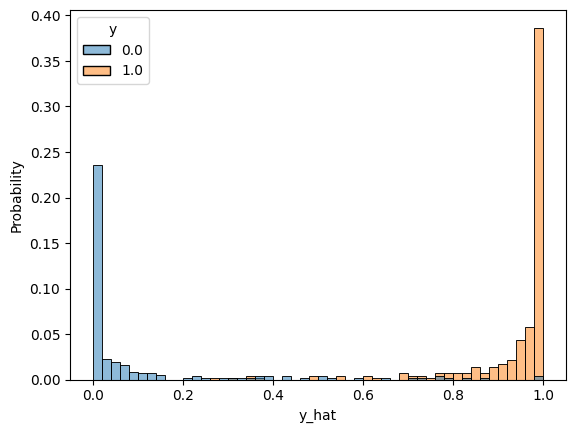

In [ ]:
df = pd.DataFrame(torch.cat([y, y_hat], dim=1).detach().numpy(), columns=['y','y_hat'])     
# 정답(y)와 예측 값(y_hat)을 열 방향으로 합치고, 텐서(그래프 제거)를 numpy 배열로 반환한 후 pandas에 전달

sns.histplot(df,x='y_hat', hue='y', bins=50, stat='probability')

plt.show()